In [99]:
from langchain.tools import tool

from dotenv import load_dotenv
from tradingbot import Ticker
from tradingbot.core.candle_storage import FileCandelStorage
from tradingbot.indicators import (
    MovingAverageConvergenceDivergence,
    SimpleMovingAverage,
)
from tradingbot.kite import KiteCandleAPIProvider, KiteSessionManager

load_dotenv()

objects = {}

@tool("login_to_kite")
def login_to_kite():
    """Logs in to Kite and stores the session manager and session in the objects dictionary."""
    try:
        if "kite_session" in objects:
            print("Already logged in to Kite.")
            return True
        session_manager = KiteSessionManager()
        session = session_manager.start_session(cli=False)
        objects["session_manager"] = session_manager
        objects["kite_session"] = session
        return True
    except Exception as e:
        print(f"Error logging in to Kite: {e}")
        return False

def indicator_mapping():
    __mapping = {
        "sma": (SimpleMovingAverage, ["period"]),
        "macd": (MovingAverageConvergenceDivergence, ["fast", "slow", "signal"]),
    }
    return __mapping

@tool("indicator_name_resolver")
def resolve_indicator_name(name):
    """
    Resolve the name key for an indicator given a user input name.
    :param name: The user input name for the indicator.
    :return: The resolved name key for the indicator, or None if not found.
    """
    lookup = name.lower().strip().replace(" ", "")
    resolver = {
        "simplemovingaverage": "sma",
        "simple_moving_average": "sma",
        "sma": "sma",
        "movingaverageconvergencedivergence": "macd",
        "moving_average_convergence_divergence": "macd",
        "macd": "macd",
    }
    return resolver.get(lookup)

@tool("indicator_param_resolver")
def resolve_indicator_params(key):
    """Resolve the required parameters for an indicator given its name key.
    :param key: The name key for the indicator (e.g., 'sma', 'macd').
    :return: A list of required parameter names for the indicator, or raises ValueError if not found.
    """
    mapping = indicator_mapping()
    if key in mapping:
        return mapping[key][1]
    else:
        raise ValueError(f"Indicator '{key}' not found in mapping.")

@tool("build_indicator")
def build_indicator(key, params:dict):
    """Build an indicator instance based on the name and parameters.
    :param key: The name key for the indicator (e.g., 'sma', 'macd').
    :param params: A dictionary of parameters required to initialize the indicator.
    :return: An instance of the indicator, or None if there was an error."""
    try:
        indicator = indicator_mapping().get(key)
        if not "indicator" in objects:
            objects["indicator"] = {}
        if indicator:
            lookup = ""
            for k,v in params.items():
                lookup += f"{k}_{v}_"
            lookup = key + "_" + lookup
            if lookup in objects["indicator"].keys():
                print(f"Indicator '{lookup}' already exists.")
                return "Indicator already exists with lookup key: " + lookup  
            objects["indicator"][lookup] = indicator[0](**params)
            return "Created indicator with lookup key: " + lookup
        return "Unrecognized indicator key: " + key
    except Exception as e:
        print(f"Error building indicator '{key}': {e}")
        return None


tools = [
    login_to_kite,
    resolve_indicator_name,
    resolve_indicator_params,
    build_indicator,]
tools_by_name = {tool.name: tool for tool in tools}

In [100]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="qwen3.5:0.8b",
                  temperature=0.9,
                    num_predict=512,
                      top_p=0.9, validate_model_on_init=True)
model_with_tools = llm.bind_tools(tools)

In [101]:
from langchain.messages import SystemMessage

system_message = SystemMessage(
content="You are a stock market assistant that fetches data, gives concise evidence-based analysis, and provides simple trade ideas with clear risk, stop loss, target, and invalidation levels without ever inventing market data or promising profit."
)
def assistant(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    system_message
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1,
    }

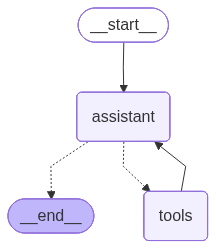

In [102]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")
builder.add_edge("assistant", END)

agent = builder.compile()
# Show the agent
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [104]:
# Invoke
from langchain.messages import HumanMessage

messages = [HumanMessage(content="Create a 50 simple moving average. ")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

Indicator 'sma_period_50_' already exists.
================================ Human Message =================================

Create a 50 simple moving average. 
================================== Ai Message ==================================
Tool Calls:
  indicator_name_resolver (cb6c4d13-98a2-4332-8d68-97c78e54018e)
 Call ID: cb6c4d13-98a2-4332-8d68-97c78e54018e
  Args:
    name: simple moving average
================================= Tool Message =================================
Name: indicator_name_resolver

sma
================================== Ai Message ==================================
Tool Calls:
  indicator_param_resolver (40385524-e787-46bf-a284-51915483d72f)
 Call ID: 40385524-e787-46bf-a284-51915483d72f
  Args:
    key: sma
================================= Tool Message =================================
Name: indicator_param_resolver

["period"]
================================== Ai Message ==================================
Tool Calls:
  indicator_name_resolver (9efe335